In [1]:
!pip install idx2numpy

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import gzip
import shutil
import urllib.request
import idx2numpy

Tuve problemas con los archivos, me decia que estaban dañados, no pude hacerlo tomando los archivos locales que yo descargué. Pedí ayuda a Gemini con otra forma de obtener los archivos y me recomendó descargarlos durectos con una URL

In [3]:
files = {
    'train_images': 'https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz',
    'train_labels': 'https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz',
    'test_images':  'https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz',
    'test_labels':   'https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz',
}

data = {}

for key, url in files.items():
    gz_path = f'{key}.gz'
    raw_path = f'{key}.idx'

    # Descargar
    urllib.request.urlretrieve(url, gz_path)

    # Descomprimir
    with gzip.open(gz_path, 'rb') as f_in, open(raw_path, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

    # Convertir a numpy array
    data[key] = idx2numpy.convert_from_file(raw_path)

# Asignación de variables
x_train, y_train = data['train_images'], data['train_labels']
x_test, y_test   = data['test_images'], data['test_labels']

print(f'Train images shape: {x_train.shape}')
print(f'Train labels shape: {y_train.shape}')
print(f'Test images shape:  {x_test.shape}')
print(f'Test labels shape:   {y_test.shape}')

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape:  (10000, 28, 28)
Test labels shape:   (10000,)


In [4]:
# Aplanar imágenes
X_train_flat = x_train.reshape(x_train.shape[0], -1)
X_test_flat  = x_test.reshape(x_test.shape[0], -1)

print(f'Nuevas dimensiones de X_train: {X_train_flat.shape}')

Nuevas dimensiones de X_train: (60000, 784)


In [5]:
# Estandarizar
scaler = StandardScaler()
X_transformed = scaler.fit_transform(X_train_flat)

In [6]:
# fit: entrenamiento
pca = PCA(n_components=2)
pca.fit(X_transformed)

PCA(n_components=2)

In [7]:
varianza = pca.explained_variance_ratio_.sum()
print(f'Varianza explicada acumulada: {varianza * 100:.2f}%')

Varianza explicada acumulada: 9.72%


In [8]:
X_pca = pca.transform(X_transformed)

In [9]:
df_pca = pd.DataFrame(X_pca, columns=["PCA1", "PCA2"])
#df_pca["label"] = y_train

df_pca.head(3)

,PCA1,PCA2
0,-0.922159,-4.814790
1,8.708977,-7.754403
2,2.328389,9.431338


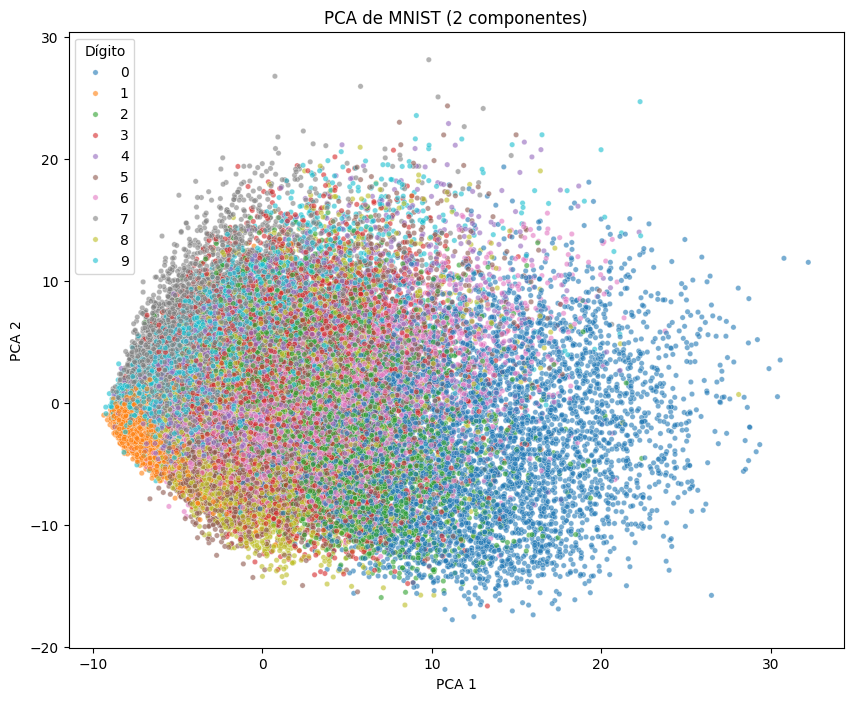

In [10]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data = df_pca,
    x = "PCA1",
    y = "PCA2",
    hue = y_train,
    palette = "tab10",
    alpha = 0.6,
    s = 15
)
plt.title("PCA de MNIST (2 componentes)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title = "Dígito")
plt.show()